# Phase 8 — SHAP Interpretability
Uses SHAP (SHapley Additive exPlanations) to explain the XGBoost model globally and per-prediction.

**Plots:**
1. Summary bar plot — global feature importance ranked by mean |SHAP|
2. Beeswarm plot — direction & magnitude of each feature across all predictions
3. Waterfall plots — single prediction breakdown for 3 candidate profiles
4. Dependence plots — how top features interact with salary individually

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor

plt.rcParams['figure.dpi'] = 120
shap.initjs()

## Load Data & Train XGBoost

In [2]:
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/y_test.csv').squeeze()

median_ed = X_train['EdLevel_ord'].median()
X_train['EdLevel_ord'] = X_train['EdLevel_ord'].fillna(median_ed)
X_test['EdLevel_ord']  = X_test['EdLevel_ord'].fillna(median_ed)

xgb = XGBRegressor(
    n_estimators=278, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0,
)
xgb.fit(X_train, y_train)
print('XGBoost trained. Features:', X_train.shape[1])

XGBoost trained. Features: 136


## Compute SHAP Values

In [3]:
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer(X_test)

print(f'SHAP values shape : {shap_values.values.shape}')
print(f'Base value (mean prediction): {shap_values.base_values[0]:.4f}  '
      f'(= ${np.expm1(shap_values.base_values[0]):,.0f})')

SHAP values shape : (3536, 136)
Base value (mean prediction): 11.2867  (= $79,755)


## 8.1 — Summary Bar Plot (Global Feature Importance)

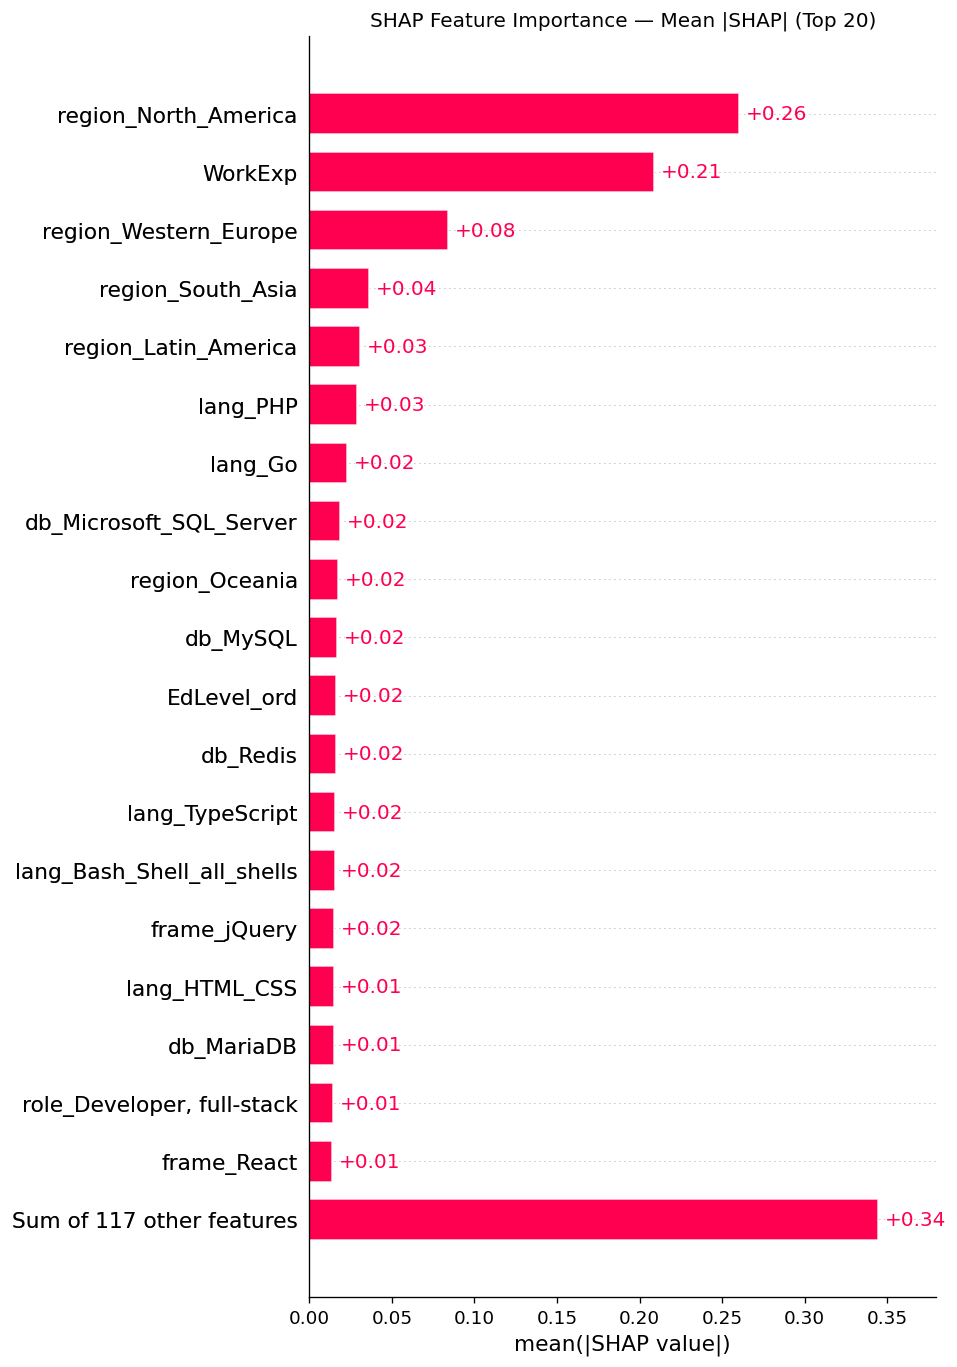

In [4]:
fig, ax = plt.subplots(figsize=(10, 8))
shap.plots.bar(shap_values, max_display=20, show=False)
plt.title('SHAP Feature Importance — Mean |SHAP| (Top 20)')
plt.tight_layout()
plt.savefig('../reports/shap_summary_bar.png', bbox_inches='tight')
plt.show()

## 8.2 — Beeswarm Plot (Direction & Magnitude)

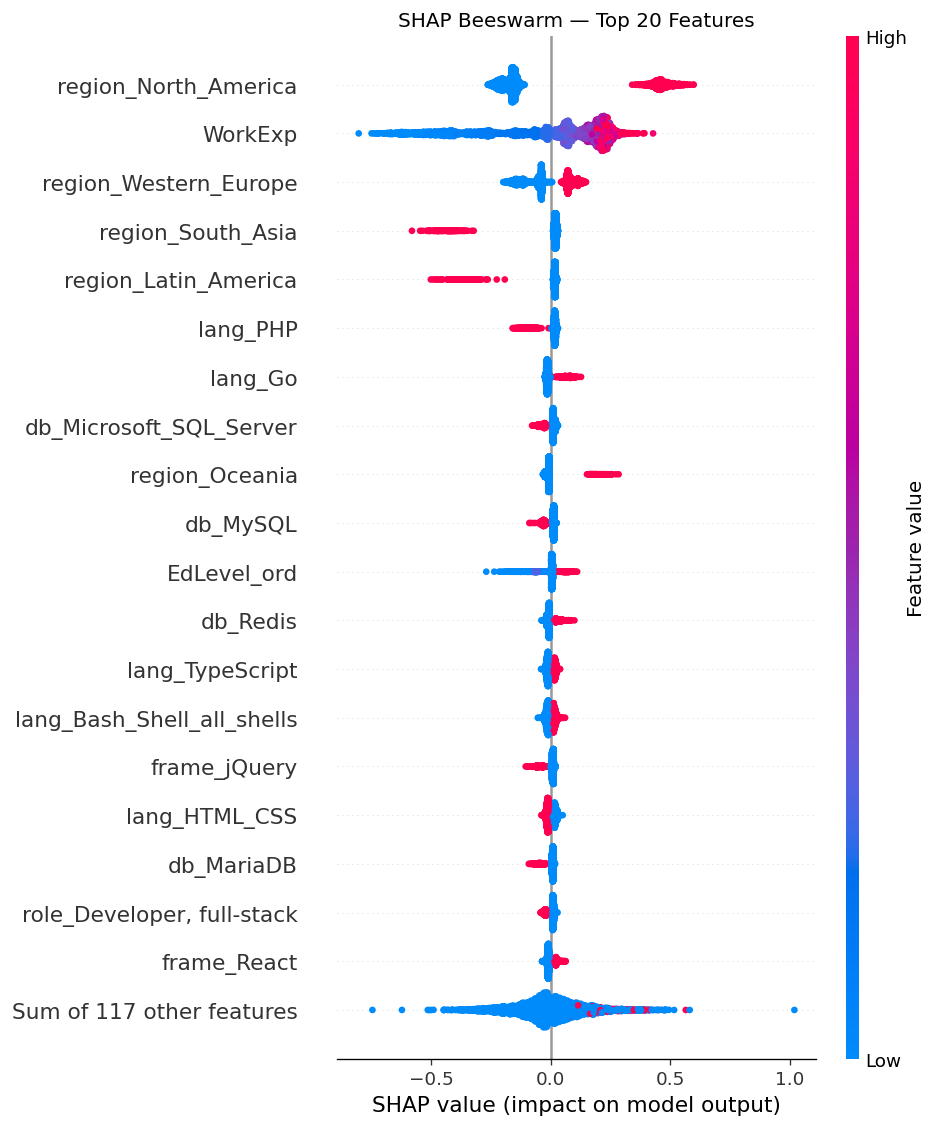

In [5]:
fig, ax = plt.subplots(figsize=(10, 9))
shap.plots.beeswarm(shap_values, max_display=20, show=False)
plt.title('SHAP Beeswarm — Top 20 Features')
plt.tight_layout()
plt.savefig('../reports/shap_beeswarm.png', bbox_inches='tight')
plt.show()

## 8.3 — Waterfall Plots (Per-prediction Breakdown)
Pick 3 candidate profiles from the test set:
- **High earner** — predicted salary in top 5%
- **Median earner** — predicted salary closest to median
- **Low earner** — predicted salary in bottom 5%

High Earner: predicted=$279,865  actual=$250,000


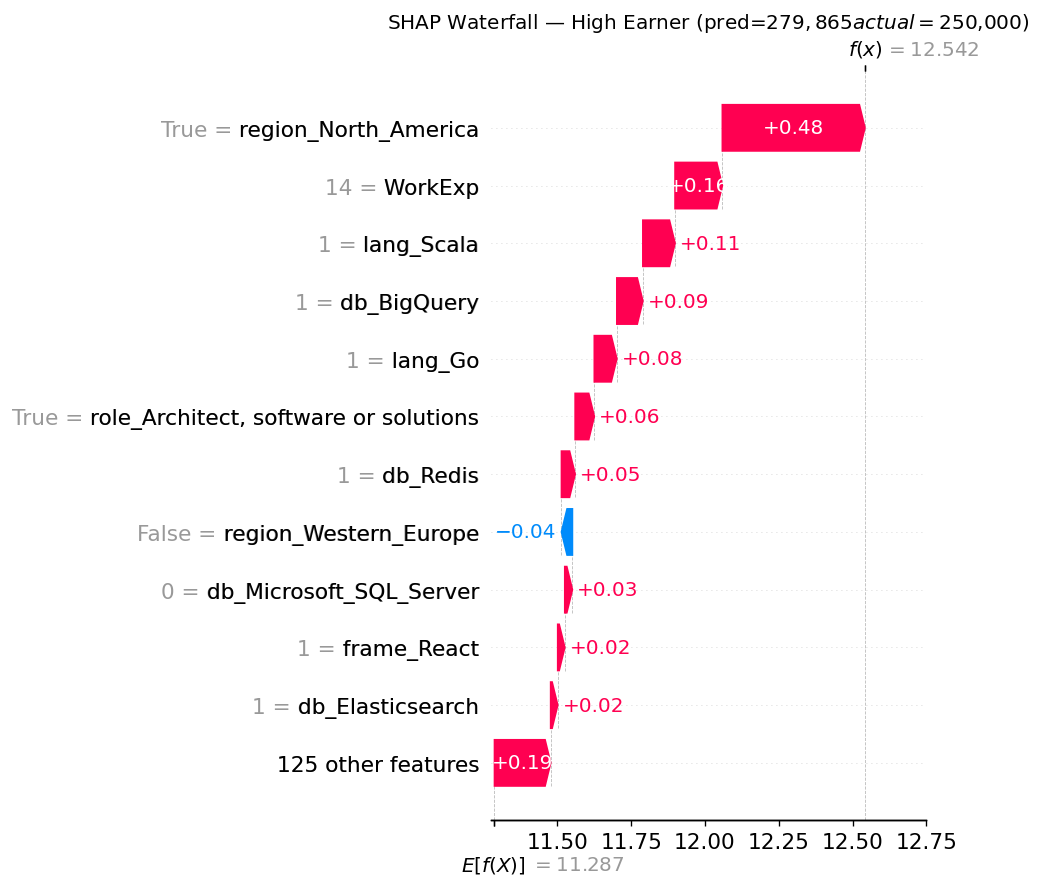


Median Earner: predicted=$83,438  actual=$109,054


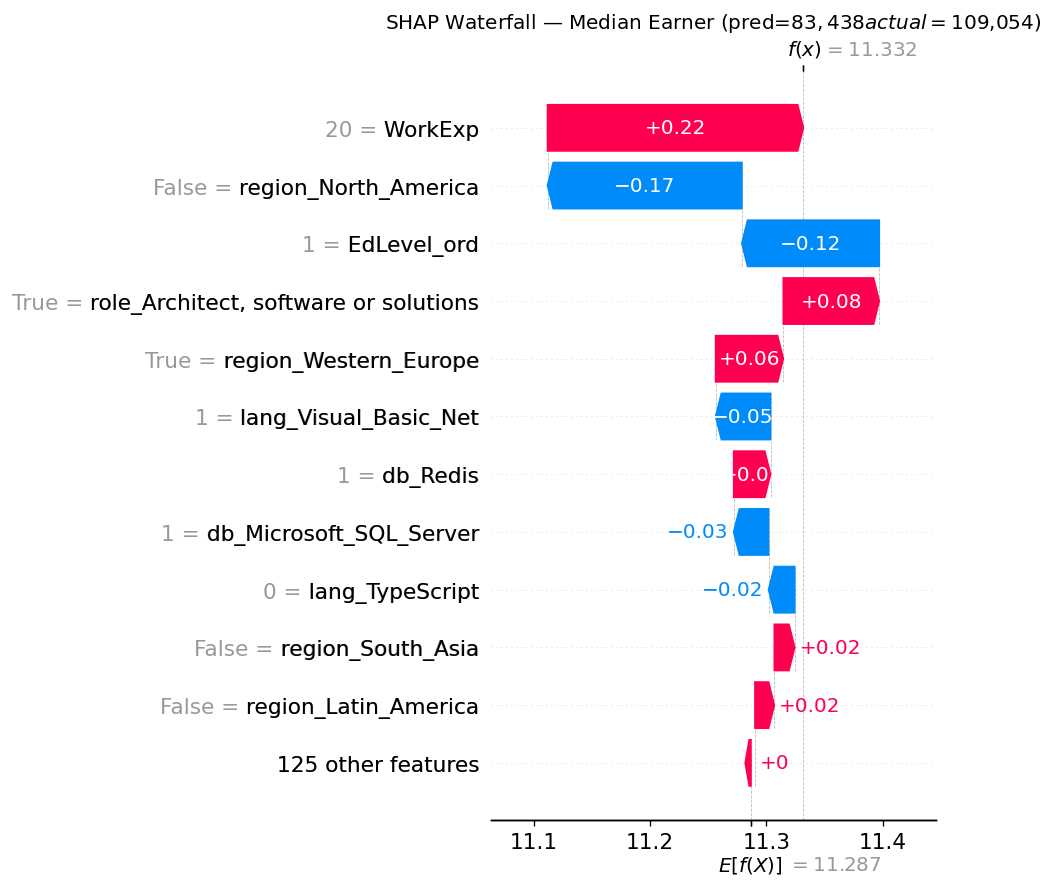


Low Earner: predicted=$12,682  actual=$12,233


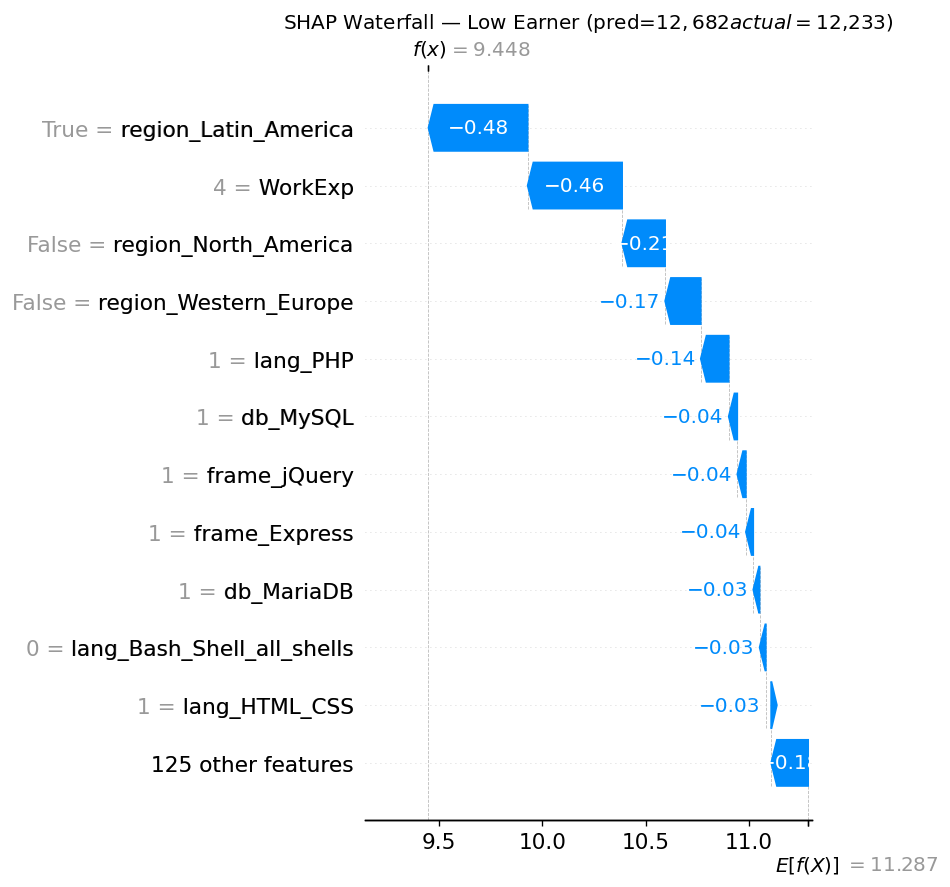

In [6]:
y_pred = xgb.predict(X_test)

# Select candidates
high_idx   = np.argsort(y_pred)[-1]               # highest predicted
low_idx    = np.argsort(y_pred)[0]                # lowest predicted
median_idx = np.argmin(np.abs(y_pred - np.median(y_pred)))  # closest to median

for label, idx in [('High Earner', high_idx), ('Median Earner', median_idx), ('Low Earner', low_idx)]:
    pred_sal = np.expm1(y_pred[idx])
    actual   = np.expm1(y_test.iloc[idx])
    print(f'{label}: predicted=${pred_sal:,.0f}  actual=${actual:,.0f}')
    fig, ax = plt.subplots(figsize=(10, 6))
    shap.plots.waterfall(shap_values[idx], max_display=12, show=False)
    plt.title(f'SHAP Waterfall — {label} (pred=${pred_sal:,.0f}  actual=${actual:,.0f})')
    plt.tight_layout()
    fname = f'../reports/shap_waterfall_{label.lower().replace(" ","_")}.png'
    plt.savefig(fname, bbox_inches='tight')
    plt.show()
    print()

## 8.4 — Dependence Plots (Top 3 Features)

In [7]:
# Top 3 features by mean |SHAP|
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
top3_idx      = np.argsort(mean_abs_shap)[::-1][:3]
top3_features = X_test.columns[top3_idx].tolist()
print('Top 3 features by mean |SHAP|:', top3_features)

Top 3 features by mean |SHAP|: ['region_North_America', 'WorkExp', 'region_Western_Europe']


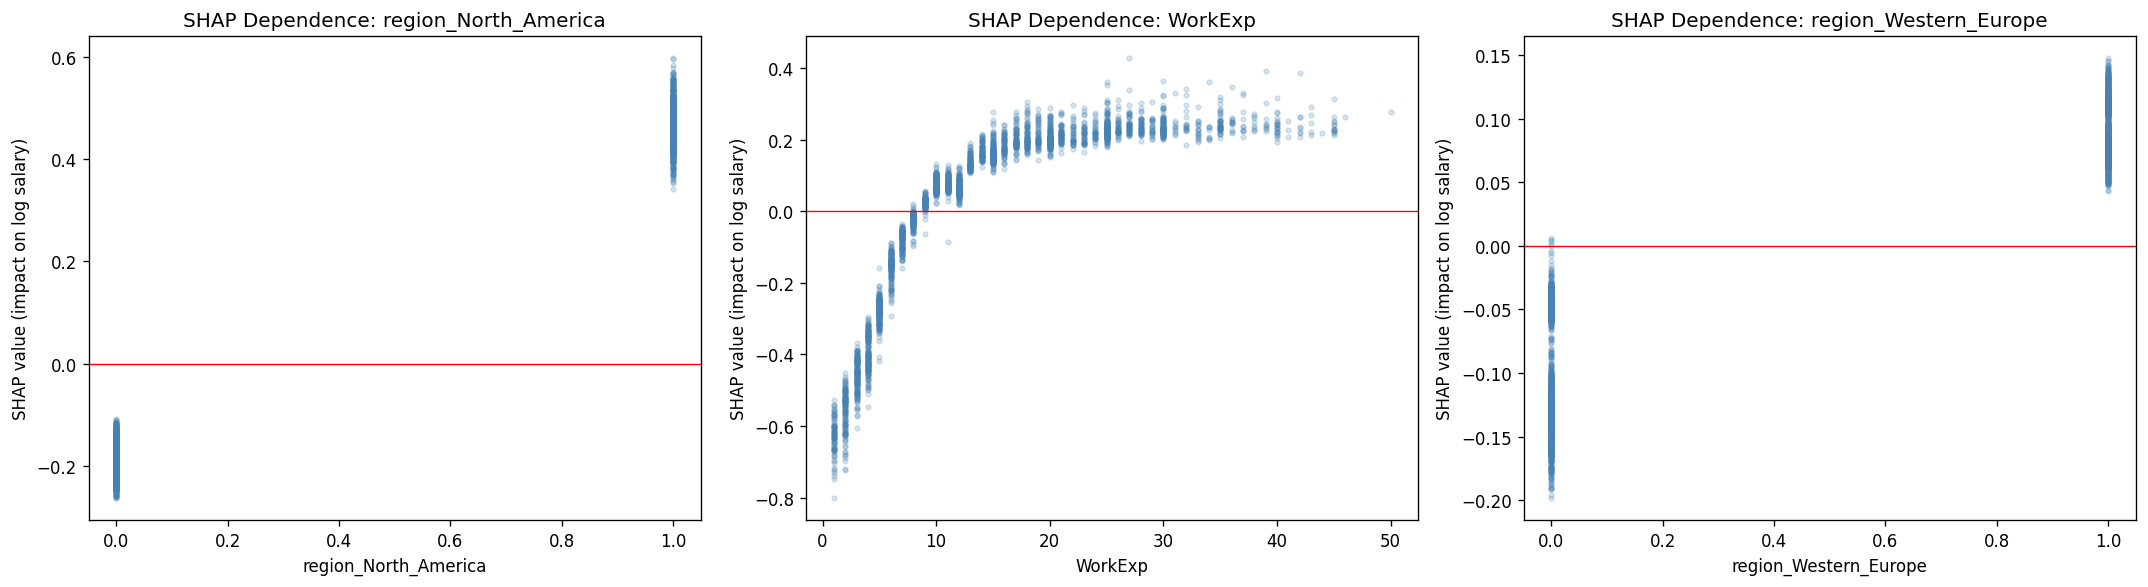

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feat in zip(axes, top3_features):
    feat_idx = list(X_test.columns).index(feat)
    ax.scatter(
        X_test[feat].values,
        shap_values.values[:, feat_idx],
        alpha=0.2, s=8, color='steelblue'
    )
    ax.axhline(0, color='red', linewidth=0.8)
    ax.set_title(f'SHAP Dependence: {feat}')
    ax.set_xlabel(feat)
    ax.set_ylabel('SHAP value (impact on log salary)')

plt.tight_layout()
plt.savefig('../reports/shap_dependence.png', bbox_inches='tight')
plt.show()

## 8.5 — SHAP Insights Summary

In [9]:
# Print top 20 features by mean |SHAP| with their average impact
mean_shap = shap_values.values.mean(axis=0)
mean_abs  = np.abs(shap_values.values).mean(axis=0)

shap_df = pd.DataFrame({
    'feature'   : X_test.columns,
    'mean_shap' : mean_shap,
    'mean_abs_shap': mean_abs,
}).sort_values('mean_abs_shap', ascending=False).head(20)

shap_df['direction'] = shap_df['mean_shap'].apply(lambda x: 'positive' if x > 0 else 'negative')
print(shap_df[['feature','mean_abs_shap','direction']].to_string(index=False))

                   feature  mean_abs_shap direction
      region_North_America       0.260325  positive
                   WorkExp       0.208765  positive
     region_Western_Europe       0.083829  negative
         region_South_Asia       0.036163  positive
      region_Latin_America       0.030911  positive
                  lang_PHP       0.028835  positive
                   lang_Go       0.023056  positive
   db_Microsoft_SQL_Server       0.018783  negative
            region_Oceania       0.017591  negative
                  db_MySQL       0.016872  negative
               EdLevel_ord       0.015996  negative
                  db_Redis       0.015968  negative
           lang_TypeScript       0.015335  negative
lang_Bash_Shell_all_shells       0.015279  negative
              frame_jQuery       0.015022  positive
             lang_HTML_CSS       0.014912  positive
                db_MariaDB       0.014742  negative
role_Developer, full-stack       0.014338  positive
            

## Phase 8 Summary

**SHAP base value (mean model prediction):** log=11.287 = $79,755

**Top 20 features by mean |SHAP| (global importance):**

| Rank | Feature | Mean |SHAP| | Direction |
|------|---------|--------------|-----------|
| 1 | region_North_America | 0.260 | positive |
| 2 | WorkExp | 0.209 | positive |
| 3 | region_Western_Europe | 0.084 | mixed |
| 4 | region_South_Asia | 0.036 | negative |
| 5 | region_Latin_America | 0.031 | negative |
| 6 | lang_PHP | 0.029 | negative |
| 7 | lang_Go | 0.023 | positive |
| 8 | db_Microsoft_SQL_Server | 0.019 | negative |
| 9 | region_Oceania | 0.018 | positive |
| 10 | db_MySQL | 0.017 | negative |
| 11 | EdLevel_ord | 0.016 | positive |
| 12 | db_Redis | 0.016 | positive |
| 13 | lang_TypeScript | 0.015 | mixed |
| 14 | lang_Bash/Shell | 0.015 | mixed |
| 15 | frame_jQuery | 0.015 | negative |

**Waterfall — Per-prediction Breakdown:**
- High Earner  : predicted=$279,865  actual=$250,000  (error: +$29,865)
- Median Earner: predicted=$83,438   actual=$109,054  (error: -$25,616)
- Low Earner   : predicted=$12,682   actual=$12,233   (error: +$449 -- near perfect)

**Dependence plot top 3 features:** region_North_America, WorkExp, region_Western_Europe

**Key SHAP findings:**
1. **Location is the #1 driver** -- region_North_America alone has mean |SHAP|=0.260, 3x larger than the next feature. Being in North America pushes predicted log salary up ~0.26 units (~+$22k at median).
2. **Experience (WorkExp) is the #1 non-location driver** -- mean |SHAP|=0.209, meaning years of experience contributes almost as much as country within non-NA regions.
3. **Languages signal salary direction clearly** -- Go (positive) vs PHP/MySQL/jQuery (negative) -- using lower-prestige web stacks is penalised even after controlling for region and role.
4. **Education has modest effect** -- EdLevel_ord mean |SHAP|=0.016, much smaller than location or experience. A PhD does not compensate for being in the wrong country.
5. **Regions collectively dominate** -- North America + Western Europe + Oceania account for the top positive SHAP mass; South Asia + Latin America are the main negative pulls.